### Import Libraries

In [8]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Load Dataset

In [11]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to [0,1]
x_train =x_train / 255.0
x_test = x_test / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Training dataset shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing dataset shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training dataset shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing dataset shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


### Display sample images

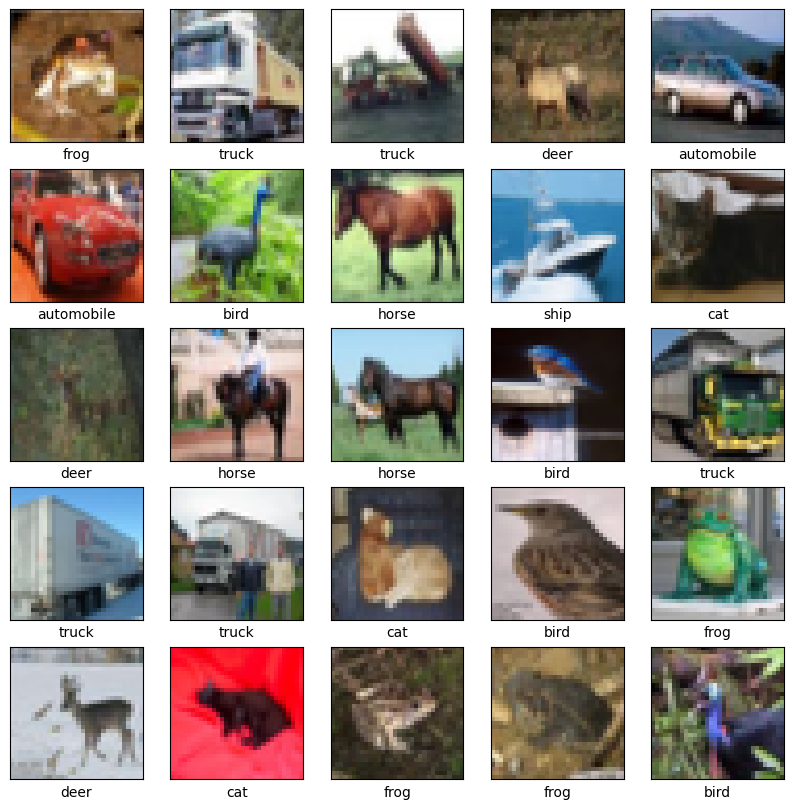

In [13]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

### Build CNN Model

In [17]:
model = models.Sequential()

#First convolution block
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

#Second convolution block
model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

#Third convolution block
model.add(layers.Conv2D(
    filters=128,
    kernel_size=(3, 3),
    activation='relu'))

#Flatten layer
model.add(layers.Flatten())

#Fully connected layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

#Output layer
model.add(layers.Dense(10, activation='softmax'))

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Compile Model

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train Model

In [19]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1

)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 97ms/step - accuracy: 0.3834 - loss: 1.6765 - val_accuracy: 0.4936 - val_loss: 1.3740
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.5202 - loss: 1.3461 - val_accuracy: 0.5926 - val_loss: 1.1690
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 92ms/step - accuracy: 0.5822 - loss: 1.1922 - val_accuracy: 0.6002 - val_loss: 1.1078
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.6211 - loss: 1.0856 - val_accuracy: 0.6607 - val_loss: 0.9681
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.6510 - loss: 0.9989 - val_accuracy: 0.6734 - val_loss: 0.9276
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 108ms/step - accuracy: 0.6748 - loss: 0.9310 - val_accuracy: 0.6841 - val_loss: 0.8993
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 139ms/step - accuracy: 0.7005 - loss: 0.8724 - val_accuracy: 0.6936 - val_loss: 0.8785
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 92ms/step - accuracy: 0.7153 - loss: 0.820

### Plot Accuracy and Loss

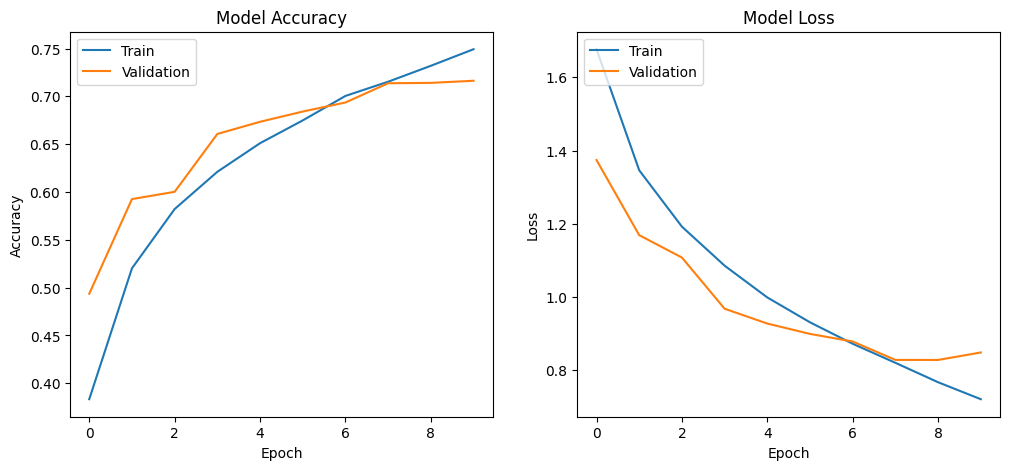

In [21]:
plt.figure(figsize=(12,5))

#Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label="Validation")
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

### Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


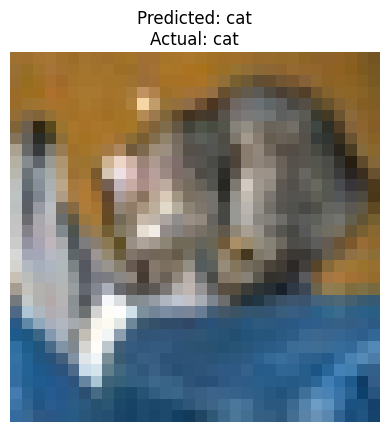

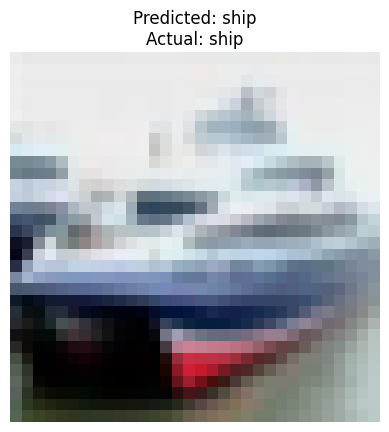

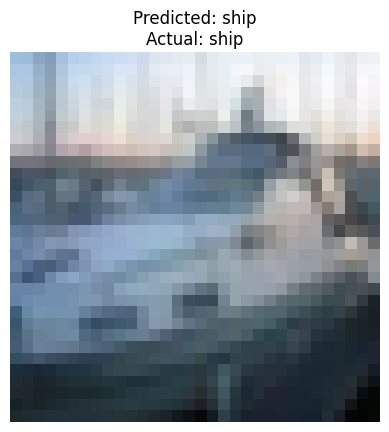

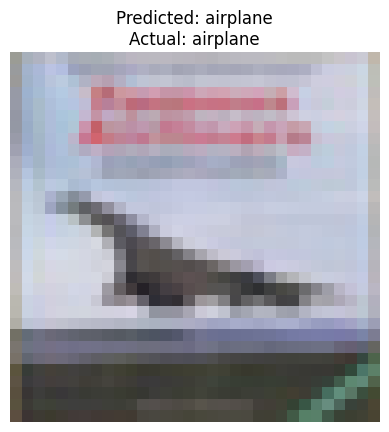

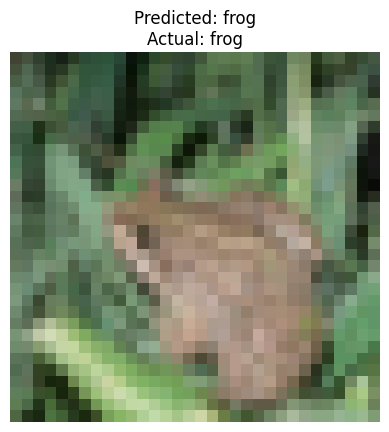

In [22]:
predictions = model.predict(x_test)

for i in range(5):
    predicted_lable= np.argmax(predictions[i])
    actual_label = y_test[i][0]

    plt.figure(i)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.title(f"Predicted: {class_names[predicted_lable]}\nActual: {class_names[actual_label]}")
    plt.axis("off")
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


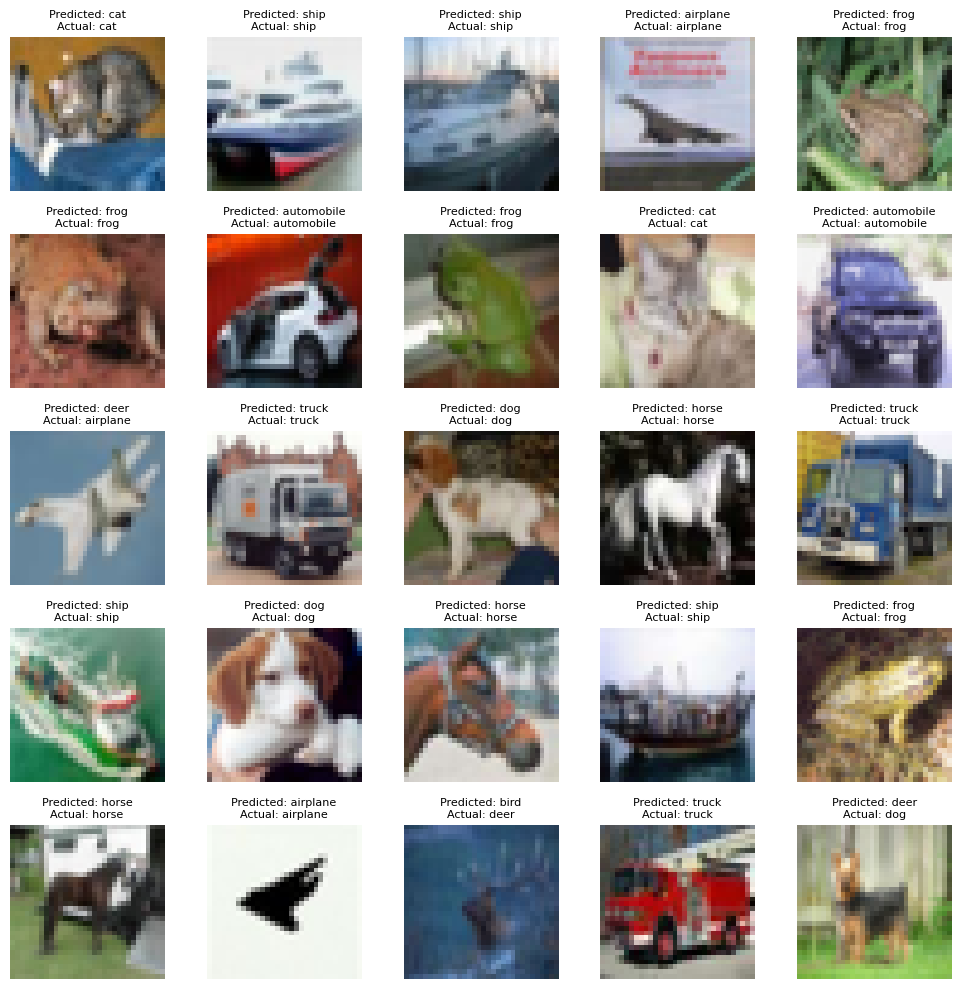

In [26]:
predictions = model.predict(x_test)

plt.figure(figsize=(10, 10))

for i in range(25):  # Display first 25 images
    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i][0]   # or y_test[i] if labels are 1D

    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {class_names[actual_label]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Confusion Matrix

<Figure size 1000x1000 with 0 Axes>

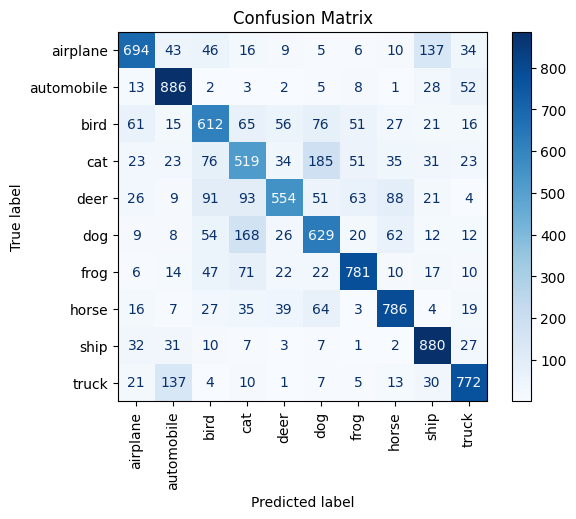

In [24]:
#Predicted Labels
y_pred = np.argmax(predictions, axis=1)

#True Labels
y_true = y_test.flatten()

#Computer Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

#Display Confusion Matrix
plt.figure(figsize=(10,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title('Confusion Matrix')
plt.show()
